# Predicción de la Calidad del Agua de la India mediante Redes Neuronales con Keras

**Pontificia Universidad Javeriana**  
**Procesamiento de Big Data · 2026**

Este cuaderno documenta el flujo técnico usado para construir un modelo predictivo del **Water Quality Index (WQI)** a partir de variables fisicoquímicas de calidad del agua. La estructura sigue el informe académico adjunto: descripción de datos, preparación, análisis exploratorio, cálculo del WQI, visualización geográfica y entrenamiento de una red neuronal con Keras.

**Objetivo del cuaderno:** procesar el conjunto de datos `waterquality.csv`, calcular subíndices de calidad, construir el índice WQI, visualizar patrones espaciales en India y entrenar un modelo de regresión para predecir el WQI.


## Índice del cuaderno

1. Importación de bibliotecas  
2. Carga de datos  
3. Análisis y preparación de datos  
4. Preparación de variables para visualización  
5. Análisis exploratorio de datos  
6. Construcción de subíndices de calidad  
7. Cálculo y clasificación del WQI  
8. Visualización geográfica  
9. Modelo de red neuronal con Keras  
10. Comparativa de métricas: entrenamiento vs. prueba  
11. Conclusiones, observaciones y referencias

## 1. Importación de bibliotecas

En esta sección se cargan las librerías necesarias para el procesamiento distribuido, análisis de datos, visualización y modelado predictivo. El cuaderno utiliza principalmente **PySpark** para la transformación de datos, **Pandas/Numpy** para manipulación tabular, **Matplotlib/Seaborn** para gráficos, **GeoPandas** para mapas y **Keras/TensorFlow** para la red neuronal.


### 1.1 Preparación del entorno

Se agregan rutas del sistema y se importan los paquetes base. Esta configuración permite trabajar con Spark dentro del entorno de ejecución del cuaderno.


In [1]:
import os

import sys

sys.path.append('/usr/lib/python3/dist-packages/')

import numpy as np

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt

from pylab import *

import findspark

findspark.init()

import pyspark.sql.functions as F

from pyspark import SparkConf, SparkContext

from pyspark.sql import SQLContext

from pyspark.sql import SparkSession

from pyspark.sql.types import *

### 1.2 Creación de la sesión Spark

Se inicializa una sesión local de Spark llamada `Calidad_Agua_Alvarez`. Esta sesión permite leer el archivo CSV, transformar columnas, crear vistas temporales SQL y calcular nuevas variables de forma distribuida.


In [2]:
configura = SparkConf()

configura.setAppName("Calidad_Agua_Alvarez")

#despues quitar
configura.setMaster("local[*]")


sparkAlvarez = SparkSession.builder.config(conf=configura).getOrCreate()

SQLContext(sparkContext=sparkAlvarez.sparkContext, sparkSession=sparkAlvarez)

sparkContextoS = sparkAlvarez.sparkContext.getOrCreate()

print("Sesion creada: ProcesamientoDatos04")

sparkAlvarez

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/27 08:14:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/27 08:14:32 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/27 08:14:32 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/04/27 08:14:32 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


Sesion creada: ProcesamientoDatos04


## 2. Carga de datos

Se carga el archivo `waterquality.csv`, correspondiente a mediciones fisicoquímicas de calidad del agua en ríos de la India. Cada fila representa registros asociados a estaciones de monitoreo y contiene variables como temperatura, oxígeno disuelto, pH, conductividad, demanda bioquímica de oxígeno, nitratos/nitritos y coliformes fecales.


In [3]:
# !/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv

df00 = sparkAlvarez.read.format("csv").option("header", "true").load("waterquality.csv")

df00.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|         371|5.6|               3.55|            90|           283|
|        2183|GODAVARI RIVER AT...|MAHARASHTRA|25.7|5.7|7.9|         294|3.2|               2.69|       

## 3. Análisis y preparación de datos

Esta etapa corresponde a la presentación y descripción de los datos del informe. Primero se revisan las columnas disponibles, luego se exploran estadísticas generales y finalmente se valida la existencia de valores nulos o inconsistentes antes de calcular el índice de calidad del agua.


Se listan las columnas del DataFrame para confirmar que las variables esperadas fueron cargadas correctamente.


In [4]:
##Conocimiento de las columnas
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

### 3.1 Diccionario inicial de variables

Las variables principales del conjunto de datos son:

- **STATION CODE:** código de la estación de monitoreo.
- **LOCATIONS:** ubicación o río monitoreado.
- **STATE:** estado de la India donde se ubica la medición.
- **TEMP:** temperatura del agua superficial en °C.
- **DO:** oxígeno disuelto en mg/L; valores altos suelen indicar mejor calidad.
- **pH:** medida adimensional de acidez o basicidad.
- **CONDUCTIVITY:** capacidad del agua para conducir corriente eléctrica; valores altos pueden asociarse con mineralización o contaminación.
- **BOD:** demanda bioquímica de oxígeno; valores altos suelen indicar carga orgánica.
- **NITRATE_N_NITRITE_N:** concentración combinada de nitratos y nitritos.
- **FECAL_COLIFORM:** indicador microbiológico de contaminación fecal.


### 3.2 Estadísticas descriptivas

Se calculan estadísticas básicas por columna para conocer rangos, conteos y posibles comportamientos atípicos. Esta revisión ayuda a identificar variables que requieren conversión de tipo, limpieza o tratamiento antes del análisis.


El siguiente ciclo calcula estadísticas descriptivas para cada columna. Esto ayuda a observar conteos, mínimos, máximos y posibles valores extremos.


In [5]:
for valor in df00.columns:
    df00.describe([valor]).show()

+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+

+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+

+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+

+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+---------

### 3.3 Revisión de valores nulos o imposibles

Antes de construir el modelo, se verifica si existen valores nulos en las columnas. Esta validación es importante porque el cálculo del WQI depende de varios parámetros fisicoquímicos y cualquier dato faltante puede afectar el resultado final.


La siguiente celda cuenta valores nulos por columna usando funciones de Spark.


In [6]:
#Cantidad de Valores Nulos o Imposibles

df00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df00.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



**Observación inicial:** se valida la estructura de los datos y se crea una vista temporal para facilitar consultas SQL desde Spark. Esta vista será usada en las siguientes transformaciones y visualizaciones.


Se crea una vista temporal SQL para consultar el DataFrame con instrucciones Spark SQL.


In [7]:
#Se crea una vista para ser usada en las visualizaciones
df00.createOrReplaceTempView("df00_sql")

Se crea `df01` como DataFrame de trabajo a partir de la vista temporal.


In [8]:
df01 = sparkAlvarez.sql('''Select * from df00_sql''')

Se repite la validación de nulos sobre el nuevo DataFrame de trabajo `df01`, que corresponde a la copia consultada desde la vista temporal `df00_sql`.


In [9]:
df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



### 3.4 Tratamiento de tipos de datos

El archivo CSV carga inicialmente muchas columnas como texto. Para poder graficar, calcular rangos de calidad y entrenar el modelo, las variables fisicoquímicas se convierten a tipos numéricos, especialmente `FloatType`.


A continuación se convierten las variables fisicoquímicas a tipo numérico para poder operar matemáticamente sobre ellas.


In [10]:
df00.dtypes
##Se procede a cambiar los tipos de datos
df00 = df00.withColumn('TEMP', df00['TEMP'].cast(FloatType()))
df00 = df00.withColumn('pH', df00['pH'].cast(FloatType()))
df00 = df00.withColumn('DO', df00['DO'].cast(FloatType()))
df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(FloatType()))
df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))
df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(FloatType()))
df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))
df00.dtypes


##Se elimina la columna TOTAL_COLIFORM
df01 = df00.drop('TOTAL_COLIFORM')
df01.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM']

## 4. Preparación de variables para visualización

Se crean consultas individuales para extraer cada parámetro de calidad del agua. Luego se convierten en listas o arreglos para facilitar su graficación con Matplotlib.


Se registra el DataFrame como vista temporal y se preparan estructuras auxiliares para graficar cada variable.


In [11]:
#Se hace uso de la función LAMBDA para hacer el tratamiento/limpieza de los datos

df01.createOrReplaceTempView("df01_sql")

Extracción del vector de oxígeno disuelto (`DO`) para análisis y visualización.


In [12]:
###Se crea una consulta por cada parámetro DO
do_parametro = sparkAlvarez.sql("Select DO from df01_sql")
##Se hace una consulta para crear el vector de la tabla por cada parámetro
do_parametro = do_parametro.rdd.map(lambda fila: fila.DO).collect()

Extracción del vector de pH para análisis y visualización.


In [13]:
###Se crea una consulta por cada parámetro PH
ph_parametro = sparkAlvarez.sql("Select pH from df01_sql")
##Se hace una consulta para crear el vector de la tabla por cada parámetro
ph_parametro = ph_parametro.rdd.map(lambda fila: fila.pH).collect()

Extracción del vector de conductividad para análisis y visualización.


In [14]:
###Se crea una consulta por cada parámetro CONDUCTIVITY
COND_parametro = sparkAlvarez.sql("Select CONDUCTIVITY from df01_sql")
##Se hace una consulta para crear el vector de la tabla por cada parámetro
COND_parametro = COND_parametro.rdd.map(lambda fila: fila.CONDUCTIVITY).collect()

Extracción del vector de BOD para análisis y visualización.


In [15]:
###Se crea una consulta por cada parámetro BOD
BOD_parametro = sparkAlvarez.sql("Select BOD from df01_sql")
##Se hace una consulta para crear el vector de la tabla por cada parámetro
BOD_parametro = BOD_parametro.rdd.map(lambda fila: fila.BOD).collect()

Extracción del vector de nitratos/nitritos para análisis y visualización.


In [16]:
###Se crea una consulta por cada parámetro NITRATE_N_NITRITE_N
NN_parametro = sparkAlvarez.sql("Select NITRATE_N_NITRITE_N from df01_sql")
##Se hace una consulta para crear el vector de la tabla por cada parámetro
NN_parametro = NN_parametro.rdd.map(lambda fila: fila.NITRATE_N_NITRITE_N).collect()

Extracción del vector de coliformes fecales para análisis y visualización.


In [17]:
###Se crea una consulta por cada parámetro FECAL_COLIFORM 
FC_parametro = sparkAlvarez.sql("Select FECAL_COLIFORM from df01_sql")
##Se hace una consulta para crear el vector de la tabla por cada parámetro
FC_parametro = FC_parametro.rdd.map(lambda fila: fila.FECAL_COLIFORM).collect()

## 5. Análisis exploratorio de datos

En esta sección se replican las visualizaciones del informe. El propósito es observar el comportamiento de variables clave antes del cálculo del índice WQI. Las gráficas permiten identificar estabilidad, variabilidad y presencia de picos o registros extremos.

### 5.1 Comportamiento de oxígeno disuelto y pH

El pH se analiza junto con el oxígeno disuelto porque ambos son indicadores básicos de estabilidad química y condiciones para la vida acuática. En el informe se destaca que el pH suele mantenerse en rangos cercanos a la neutralidad, mientras que el oxígeno disuelto puede presentar mayor variabilidad.


La siguiente gráfica permite comparar el comportamiento de DO y pH a lo largo de los registros.


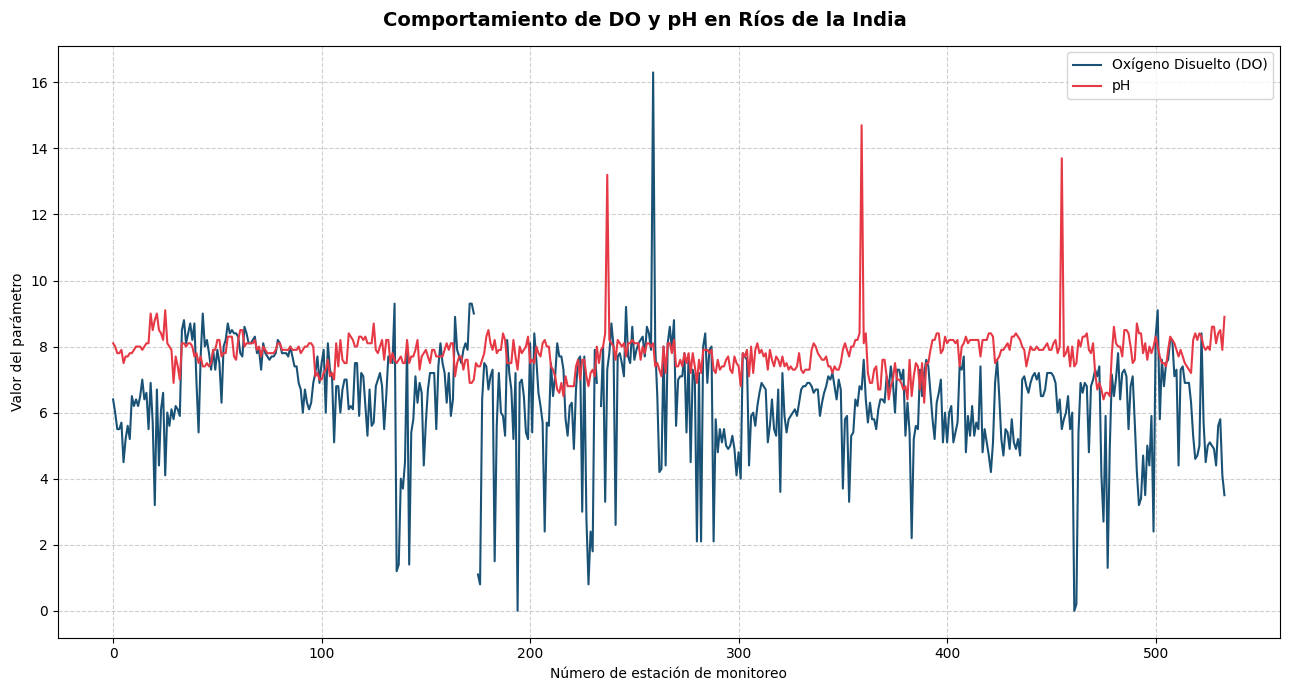

In [18]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13, 7), facecolor='w', edgecolor='k')
ax1.plot(range(0, tam), do_parametro, color='#1A5276', linewidth=1.5, label='Oxígeno Disuelto (DO)')
ax1.plot(range(0, tam), ph_parametro, color='#E63946', linewidth=1.5, label='pH')
fig.suptitle('Comportamiento de DO y pH en Ríos de la India', fontsize=14, fontweight='bold')
ax1.set_xlabel('Número de estación de monitoreo')
ax1.set_ylabel('Valor del parámetro')
legend = ax1.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


La gráfica superpone las series de DO (azul marino) y pH (rojo) a lo largo de las 534 estaciones de monitoreo, permitiendo comparar su comportamiento y variabilidad relativa.


### 5.2 Comportamiento de BOD y nitratos/nitritos

La demanda bioquímica de oxígeno se interpreta como un indicador de carga orgánica. Los nitratos y nitritos permiten observar posibles aportes asociados a actividad agrícola, escorrentía o contaminación puntual. Los picos en estas variables ayudan a identificar registros que podrían requerir análisis adicional.


La siguiente gráfica compara la demanda bioquímica de oxígeno con nitratos/nitritos.


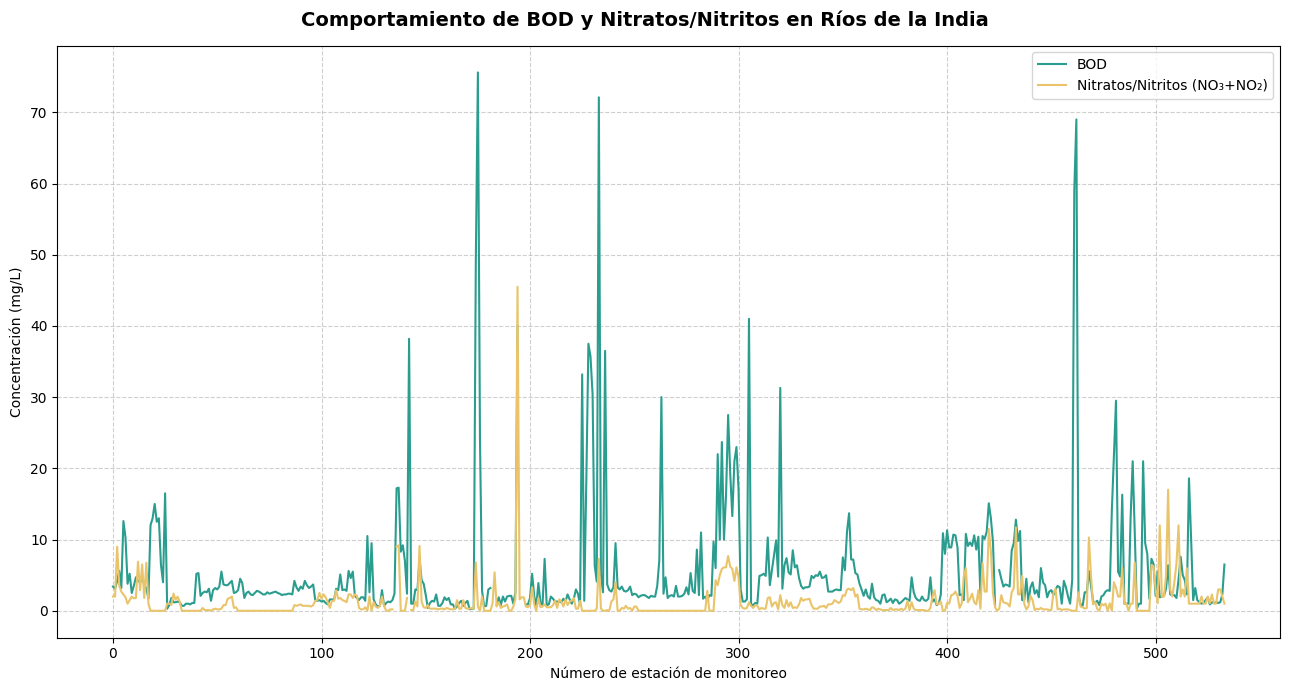

In [19]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13, 7), facecolor='w', edgecolor='k')
ax1.plot(range(0, tam), BOD_parametro, color='#2A9D8F', linewidth=1.5, label='BOD')
ax1.plot(range(0, tam), NN_parametro, color='#E9C46A', linewidth=1.5, label='Nitratos/Nitritos (NO₃+NO₂)')
fig.suptitle('Comportamiento de BOD y Nitratos/Nitritos en Ríos de la India', fontsize=14, fontweight='bold')
ax1.set_xlabel('Número de estación de monitoreo')
ax1.set_ylabel('Concentración (mg/L)')
legend = ax1.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Esta gráfica compara la demanda bioquímica de oxígeno (BOD, verde) con los nitratos/nitritos (NN, ámbar) para cada estación, revelando la naturaleza y magnitud de la carga contaminante orgánica e inorgánica.


### 5.3 Conductividad y coliformes fecales

La conductividad puede reflejar mineralización o presencia de sustancias disueltas, mientras que los coliformes fecales se relacionan con riesgos sanitarios. Por eso, estas variables son relevantes para interpretar deterioros en la calidad hídrica.


La siguiente gráfica compara conductividad y coliformes fecales.


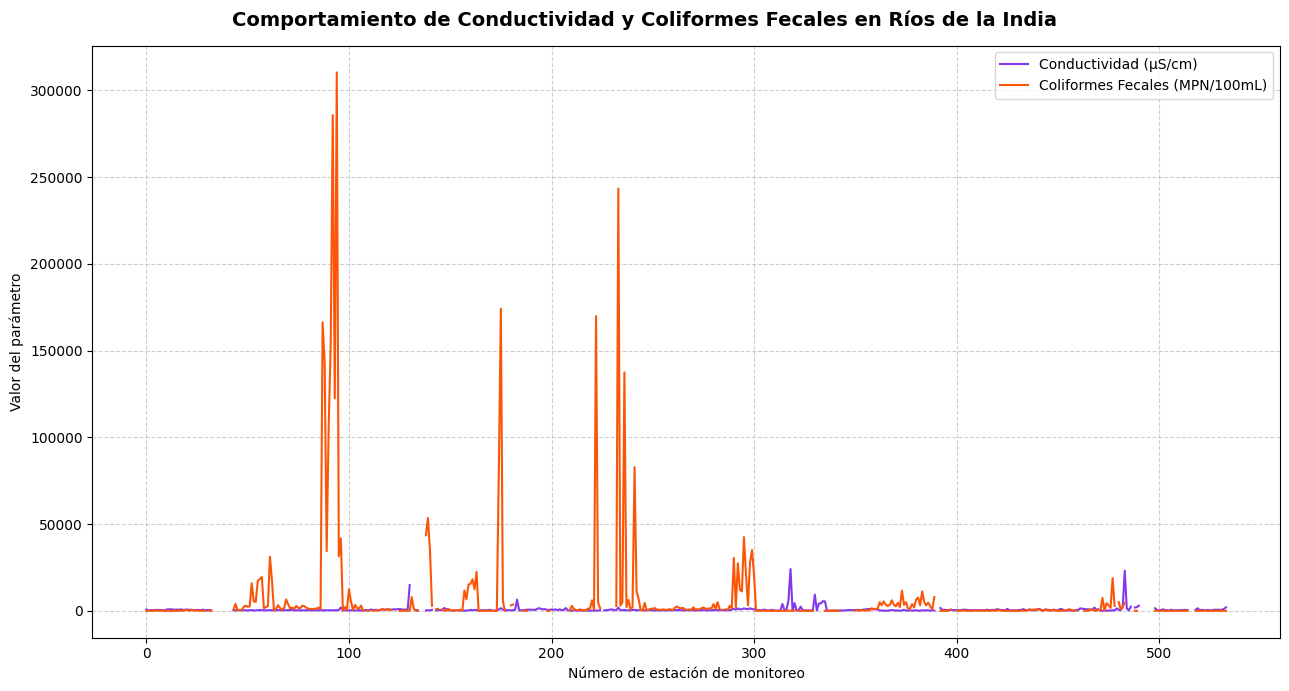

In [20]:
tam = len(do_parametro)
fig, ax1 = plt.subplots(num=None, figsize=(13, 7), facecolor='w', edgecolor='k')
ax1.plot(range(0, tam), COND_parametro, color='#8338EC', linewidth=1.5, label='Conductividad (µS/cm)')
ax1.plot(range(0, tam), FC_parametro, color='#FB5607', linewidth=1.5, label='Coliformes Fecales (MPN/100mL)')
fig.suptitle('Comportamiento de Conductividad y Coliformes Fecales en Ríos de la India', fontsize=14, fontweight='bold')
ax1.set_xlabel('Número de estación de monitoreo')
ax1.set_ylabel('Valor del parámetro')
legend = ax1.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Esta gráfica muestra conductividad eléctrica (µS/cm, morado) y coliformes fecales (MPN/100 mL, naranja), dos indicadores que reflejan tipos de contaminación muy distintos: mineralización/salinidad versus riesgo sanitario microbiológico.

## 6. Construcción de subíndices de calidad

El WQI se construye a partir de subíndices `qr`, donde cada parámetro se transforma a una escala discreta de calidad. En este cuaderno se usan cuatro niveles principales: **100** para mejor condición, **80** para condición buena, **60** para condición regular y **40** para condición deficiente. Si el valor queda fuera de los rangos definidos, se asigna 0.

### 6.1 Subíndice para pH

El pH recibe mayor puntuación cuando se encuentra en un intervalo cercano a la neutralidad, ya que valores demasiado ácidos o básicos pueden afectar la vida acuática y la potabilidad.


Se crea el primer subíndice (`qrPH`) de acuerdo con los rangos definidos para el pH.


In [21]:
#Función definida por el usuario para definir el rango de calidad de agua según el pH
#Se crea la columna para los rangos del parámetro (Según https://www.intechopen.com/chapters/69568)

df02 = df01.withColumn("qrPH", F.when((df01.pH>=7) & (df01.pH<=8.5),100).

       when(((df01.pH>=6.8) & (df01.pH<6.9)) | ((df01.pH>8.5) & (df01.pH<8.6)), 80).

       when(((df01.pH>=6.7) & (df01.pH<6.8)) | ((df01.pH>=8.6) & (df01.pH<8.8)), 60).

       when(((df01.pH>=6.5) & (df01.pH<6.7)) | ((df01.pH>=8.8) & (df01.pH<9.0)), 40).otherwise(0))

### 6.2 Subíndice para oxígeno disuelto (DO)

El oxígeno disuelto tiene un peso alto dentro del WQI porque impacta directamente las condiciones de vida de organismos acuáticos. En general, valores más altos de DO se asocian con mejor calidad del agua.


Se crea el subíndice `qrDO` para oxígeno disuelto.


In [22]:
### Función definida por el usuario para definir el rando de la calidad del agua según DO
df02 = df02.withColumn("qrDO", F.when((df01.DO>=6.0), 100).
                   when((df01.DO>=5.1) & (df01.DO<6.0), 80).
                   when((df01.DO>=4.1) & (df01.DO<5.0), 60).
                   when((df01.DO>=3.0) & (df01.DO<=4.0), 40).otherwise(0))

### 6.3 Subíndice para conductividad

La conductividad se evalúa con rangos donde los valores bajos reciben mejor puntaje. Valores elevados pueden indicar exceso de sales, mineralización o contaminación industrial.


Se crea el subíndice `qrCOND` para conductividad.


In [23]:
df02 = df02.withColumn("qrCOND", F.when(((df01.CONDUCTIVITY>=0.0) & (df01.CONDUCTIVITY<=75.0)), 100).
            when((df01.CONDUCTIVITY>75.0) & (df01.CONDUCTIVITY<=150.0), 80).
            when((df01.CONDUCTIVITY>150.0) & (df01.CONDUCTIVITY<=225.0), 60).
            when((df01.CONDUCTIVITY>225.0) & (df01.CONDUCTIVITY<=300.0), 40).otherwise(0))

### 6.4 Subíndice para demanda bioquímica de oxígeno (BOD)

El BOD mide la cantidad de oxígeno requerida para degradar materia orgánica. Un BOD bajo suele indicar menor carga orgánica y, por tanto, mejor calidad del agua.


Se crea el subíndice `qrBOD` para demanda bioquímica de oxígeno.


In [24]:
df02 = df02.withColumn("qrBOD", F.when(((df01.BOD>=0.0) & (df01.BOD<3.0)), 100).
                       when((df01.BOD>=3.0) & (df01.BOD<6.0), 80).
                       when((df01.BOD>=6.0) & (df01.BOD<80.0), 60).
                       when((df01.BOD>=80.0) & (df01.BOD<125.0), 40).otherwise(0))

### 6.5 Subíndice para nitratos y nitritos

La concentración de nitratos y nitritos se incorpora porque puede reflejar contaminación agrícola, descargas o procesos de eutrofización. Valores bajos obtienen mejor clasificación.


Se crea el subíndice `qrNN` para nitratos/nitritos.


In [25]:
df02 = df02.withColumn("qrNN", F.when(((df01.NITRATE_N_NITRITE_N>=0.0) & (df01.NITRATE_N_NITRITE_N<20.0)), 100).
                       when((df01.NITRATE_N_NITRITE_N>=20.0) & (df01.NITRATE_N_NITRITE_N<50.0), 80).
                       when((df01.NITRATE_N_NITRITE_N>=50.0) & (df01.NITRATE_N_NITRITE_N<100.0), 60).
                       when((df01.NITRATE_N_NITRITE_N>=100.0) & (df01.NITRATE_N_NITRITE_N<200.0), 40).otherwise(0))

### 6.6 Subíndice para coliformes fecales

Los coliformes fecales son un indicador sanitario crítico. Valores altos sugieren contaminación microbiológica y pueden afectar directamente la seguridad del agua para diferentes usos.


Se crea el subíndice `qrFecal` para coliformes fecales.


In [26]:
df02 = df02.withColumn("qrFecal", F.when(((df01.FECAL_COLIFORM>=0.0) & (df01.FECAL_COLIFORM<5.0)), 100).
                       when((df01.FECAL_COLIFORM>=5.0) & (df01.FECAL_COLIFORM<50.0), 80).
                       when((df01.FECAL_COLIFORM>=50.0) & (df01.FECAL_COLIFORM<500.0), 60).
                       when((df01.FECAL_COLIFORM>=500.0) & (df01.FECAL_COLIFORM<1000.0), 40).otherwise(0))

Al finalizar los cálculos anteriores, `df02` contiene los datos originales más los subíndices de calidad: `qrPH`, `qrDO`, `qrCOND`, `qrBOD`, `qrNN` y `qrFecal`.


In [27]:
#A continuación se hace una inspección en general del df02
df02.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|  80|     0|   80| 100|     60|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7.8|       371.0| 5.6|               3.55|  

In [28]:
##Nombre de Columnas
df02.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal']

## 7. Cálculo del Índice de Calidad del Agua (WQI)

El informe define el WQI como una suma ponderada de los subíndices de calidad. Cada parámetro aporta al índice final según un peso específico tomado de la literatura. Esta etapa convierte los subíndices discretos en contribuciones ponderadas.

La fórmula aplicada es:

```text
WQI = wpH + wDO + wCOND + wBOD + wNN + wFecal
```

Donde cada componente `w` corresponde al subíndice `qr` multiplicado por su peso.


Se calculan las contribuciones ponderadas de cada parámetro según los pesos definidos para el WQI.


In [29]:
###Se crea un nuevo objeto dataframe con las nuevas columnas de Indice de Calidad
df03 = df02.withColumn("wpH", F.round(df02.qrPH*0.165,3))
df03 = df03.withColumn("wDO", F.round(df03.qrDO*0.281,3))
df03 = df03.withColumn("wCOND", F.round(df03.qrCOND*0.234,3))
df03 = df03.withColumn("wBOD", F.round(df03.qrBOD*0.009,3))
df03 = df03.withColumn("wNN", F.round(df03.qrNN*0.028,3))
df03 = df03.withColumn("wFecal", F.round(df03.qrFecal*0.281,3))

In [30]:
df03.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|       

In [31]:
df03.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal']

### 7.1 Cálculo del índice final

Se suma el aporte ponderado de cada parámetro para obtener el valor final del **Water Quality Index**. Este valor resume la condición del agua en una sola métrica numérica.


In [32]:
df04 = df03.withColumn("WQI", F.round(df03.wpH+df03.wBOD+df03.wCOND+df03.wNN+df03.wFecal+df03.wDO,3))
df04.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5

### 7.3 Distribución del WQI calculado

Una vez obtenido el WQI para cada estación, se analiza su distribución para entender la calidad general del agua en el conjunto de datos. El histograma permite identificar si la mayoría de las estaciones presenta calidad baja, media o alta.

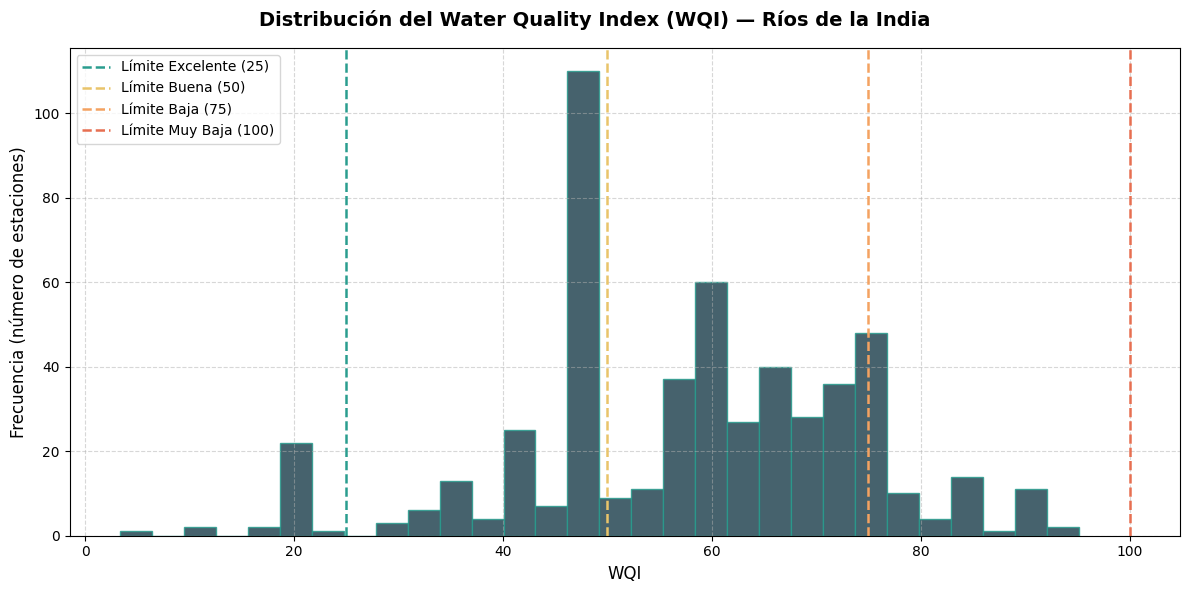

In [33]:
# ─── Histograma de distribución del WQI ───────────────────────────────────────
# Extraer el WQI como lista Python
wqi_vector = df04.select('WQI').rdd.map(lambda r: r.WQI).collect()
wqi_vector_clean = [v for v in wqi_vector if v is not None]

fig, ax = plt.subplots(figsize=(12, 6), facecolor='w')
ax.hist(wqi_vector_clean, bins=30, color='#264653', edgecolor='#2A9D8F', alpha=0.85)
fig.suptitle('Distribución del Water Quality Index (WQI) — Ríos de la India', fontsize=14, fontweight='bold')
ax.set_xlabel('WQI', fontsize=12)
ax.set_ylabel('Frecuencia (número de estaciones)', fontsize=12)

# Líneas de referencia para las categorías
for val, label, col in [(25, 'Excelente', '#2A9D8F'), (50, 'Buena', '#E9C46A'),
                         (75, 'Baja', '#F4A261'), (100, 'Muy Baja', '#E76F51')]:
    ax.axvline(val, color=col, linestyle='--', linewidth=1.8, label=f'Límite {label} ({val})')

ax.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

El histograma muestra la distribución de frecuencias del Water Quality Index (WQI) calculado para las 534 estaciones. Las líneas verticales de colores señalan los límites entre categorías de calidad.

### 7.2 Clasificación del WQI

Después de calcular el índice, se asigna una categoría de calidad. La clasificación usada en el cuaderno es:

- **Excelente:** WQI entre 0 y 25.
- **Buena:** WQI entre 25 y 50.
- **Baja:** WQI entre 50 y 75.
- **Muy baja:** WQI entre 75 y 100.
- **Inadecuada:** WQI mayor o igual a 100.

Esta clasificación facilita interpretar el resultado sin depender únicamente del valor numérico.


Se categoriza el WQI en niveles interpretables de calidad del agua.


In [34]:
df05 = df04.withColumn("CALIDAD", F.when((df04.WQI>=0) & (df04.WQI<25),'Excelente')
    .when((df04.WQI>=25) & (df04.WQI<50),'Buena')
    .when((df04.WQI>=50) & (df04.WQI<75),'Baja')
    .when((df04.WQI>=75) & (df04.WQI<100),'Muy_Baja')
    .otherwise('Inadecuada')
                      )
df05.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2

### 7.4 Distribución de categorías de calidad

El gráfico de barras complementa al histograma mostrando cuántas estaciones pertenecen a cada categoría de calidad del WQI, facilitando la comparación directa entre niveles.

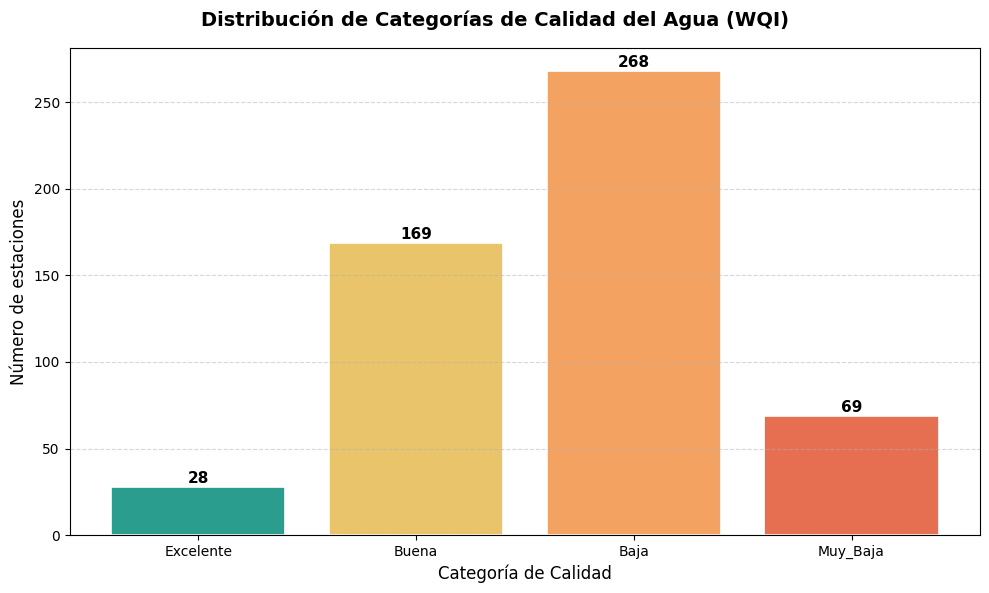

In [35]:
# ─── Gráfico de barras: conteo por categoría de CALIDAD ──────────────────────
calidad_vector = df05.select('CALIDAD').rdd.map(lambda r: r.CALIDAD).collect()
calidad_counts = {}
for c in calidad_vector:
    if c:
        calidad_counts[c] = calidad_counts.get(c, 0) + 1

# Orden lógico de categorías
orden = ['Excelente', 'Buena', 'Baja', 'Muy_Baja', 'Inadecuada']
colores = ['#2A9D8F', '#E9C46A', '#F4A261', '#E76F51', '#D62828']
etiquetas = [c for c in orden if c in calidad_counts]
valores = [calidad_counts[c] for c in etiquetas]
colors_sel = [colores[orden.index(c)] for c in etiquetas]

fig, ax = plt.subplots(figsize=(10, 6), facecolor='w')
bars = ax.bar(etiquetas, valores, color=colors_sel, edgecolor='white', linewidth=1.2)
fig.suptitle('Distribución de Categorías de Calidad del Agua (WQI)', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoría de Calidad', fontsize=12)
ax.set_ylabel('Número de estaciones', fontsize=12)

# Etiquetas sobre cada barra
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

El gráfico de barras complementa el histograma mostrando el conteo exacto de estaciones por cada categoría de calidad, facilitando la comparación directa entre niveles.


## 8. Visualización geográfica de la calidad del agua

En esta sección se integran los datos de calidad hídrica con geometrías de estados de la India. El objetivo es visualizar espacialmente el WQI y reconocer patrones territoriales.


Se identifican los estados presentes en el conjunto de datos para preparar la unión con el mapa.


In [36]:
colEstado = 'STATE'
valNomnbres = df05.select(colEstado).distinct().collect()
valNomnbres = [v[colEstado] for v in valNomnbres]

print(valNomnbres)

['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


### 8.1 Carga de mapas

Para construir los mapas se utilizan archivos shapefile (`.shp`, `.dbf`, `.shx`, `.prj`). Estos archivos deben estar en la misma carpeta para que GeoPandas pueda leer correctamente la información geográfica.


In [37]:
#Obligamos a pip a instalar geopandas en el cuaderno
import sys
!{sys.executable} -m pip install geopandas

Defaulting to user installation because normal site-packages is not writeable


Se lee el shapefile de estados de la India con GeoPandas.


In [38]:
import geopandas as gpd

rutaMapas = "Indian_States.shp"

Se inspecciona el objeto geográfico cargado.


In [39]:
## Se carga un objeto dataframe de los datos comprimidos de los mapas
gpd01 = gpd.read_file(rutaMapas)

## Se visualiza el tipo de dataframe que da geopandas y las columnas 

print(type(gpd01))

gpd01.columns

<class 'geopandas.geodataframe.GeoDataFrame'>


Index(['st_nm', 'geometry'], dtype='object')

Se revisan los nombres de estados disponibles en el shapefile para detectar diferencias con la base de calidad del agua.


In [40]:
#Se visualizan los nombres de la columna de los estados "st_nm"
gpd01["st_nm"].unique()

### Se procede a eliminar caracteres irregulares: la idea es que los estados del mapa coincidan 
### con los nombres de los estados del dataframe de datos inicial

gpd02 = gpd01.replace({'Andaman & Nicobar Island': 'Andaman Nicobar Island',
                       'Dadara & Nagar Havelli': 'Dadara Nagar Havelli',
                      'Daman & Diu': 'Daman Diu', 
                       'Jammu & Kashmir': 'Jammu Kashmir',
                       'NCT of Delhi' : 'Delhi' })
gpd02["st_nm"].unique()

array(['Andaman Nicobar Island', 'Arunanchal Pradesh', 'Assam', 'Bihar',
       'Chandigarh', 'Chhattisgarh', 'Dadara Nagar Havelli', 'Daman Diu',
       'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Lakshadweep',
       'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram',
       'Nagaland', 'Delhi', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim',
       'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh',
       'Uttarakhand', 'West Bengal', 'Odisha', 'Andhra Pradesh'],
      dtype=object)

### 8.2 Homologación de nombres y unión geográfica

Antes de unir los datos de Spark con el mapa, se estandarizan nombres de estados para que coincidan entre ambas fuentes. Luego se realiza una unión por la columna `STATE`.


Se realizan ajustes de escritura en nombres de estados para mejorar la coincidencia entre bases.


In [41]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df06 = df06.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df06.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2182|G

Se unen los datos de calidad con el mapa y se calculan coordenadas representativas para etiquetas.


In [42]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

### 8.3 Mapa base de la India

Se visualiza inicialmente el mapa sin codificar por WQI. Esta gráfica funciona como referencia territorial antes de superponer los valores del índice de calidad.


Se dibuja el mapa base de India.


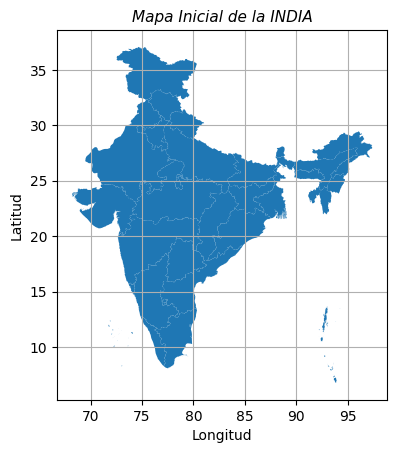

In [43]:
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title("Mapa Inicial de la INDIA", fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid()
plt.show()


El mapa base muestra la división político-administrativa de la India por estados, sin ninguna variable de calidad superpuesta. Sirve como referencia territorial y como validación de que el shapefile cargado cubre correctamente el territorio nacional.


### 8.4 Mapa coroplético del WQI

Se asigna color a cada estado según el valor de WQI. En la interpretación del informe, los valores bajos representan mejor calidad y los valores altos indican condiciones más desfavorables.


In [44]:
import sys
!{sys.executable} -m pip install adjustText
!{sys.executable} -m pip install "mapclassify >= 2.4.0"

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [45]:
from adjustText import adjust_text #Para evitar que se supermonten las etiquetas

Se genera el mapa coroplético de WQI y se agregan etiquetas con valores por estado.


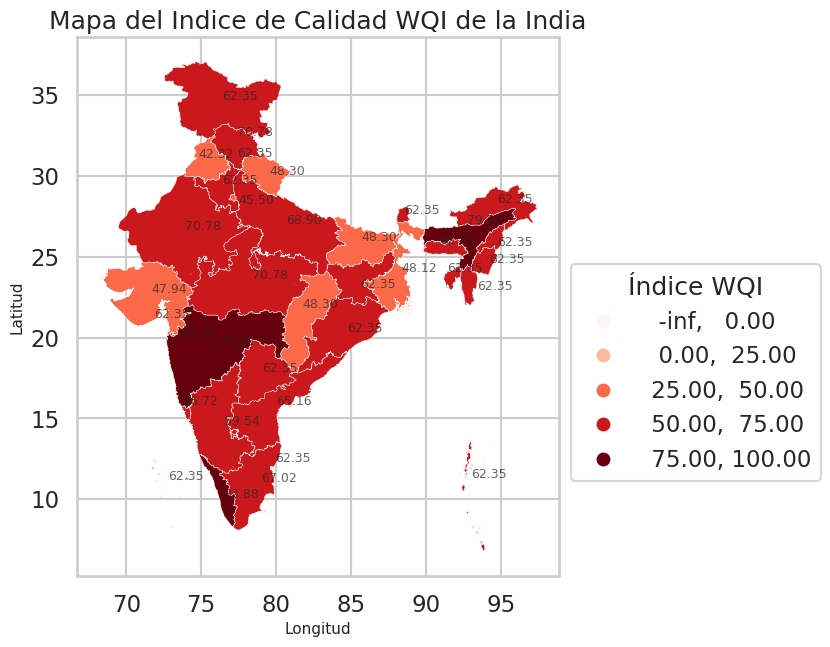

In [46]:
#Se verifica los valores NULOS; en caso de que existan se cambian por el promedio
#Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

## Configuración de Estilos para ser usados en la impresión con seaborn
sns.set_context("talk") #puede ser cualquiera
sns.set_style("whitegrid") #Puede ser cualquiera de la biblioteca de estilos de seaborn

#Se ajusta el mapa 
fig, ax = plt.subplots(figsize = (12,7))
#dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

##Ajustar la leyenda
leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

## Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=9, alpha=0.7)
        textos.append(texto)
    
#Ajustar texto de etiquetas
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

### CARPINTERIA
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.show()


El mapa asigna una tonalidad de rojo a cada estado según su valor de WQI promedio, donde los colores más intensos indican peor calidad del agua. Las etiquetas numéricas muestran el valor exacto del WQI por estado.


### 8.5 Histograma del WQI por estado

El histograma horizontal permite comparar de forma directa los valores del WQI entre estados. Esta visualización complementa el mapa porque facilita identificar qué estados tienen mejores o peores valores del índice.


Se agregan valores por estado y se construye el gráfico comparativo del WQI.


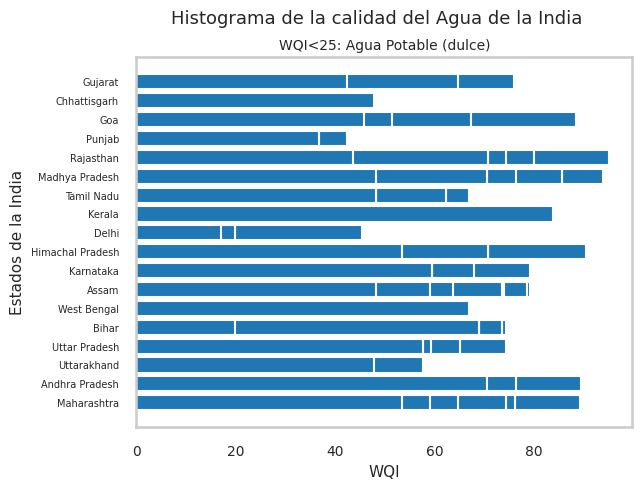

In [47]:
df06.createOrReplaceTempView("df06_sql")
#Se seleccionan los nombres de los estados
Estados = sparkAlvarez.sql("Select STATE from df06_sql")
Estados = Estados.rdd.map(lambda row: row.STATE).collect()

## Seleccionamos los valores de WQI
wqi = sparkAlvarez.sql("Select WQI from df06_sql")
wqi = wqi.rdd.map(lambda row: row.WQI).collect()

##Se grafica el histograma
plt.barh(Estados,wqi)
plt.suptitle("Histograma de la calidad del Agua de la India", fontsize=13)
plt.title("WQI<25: Agua Potable (dulce)", fontsize=10)
plt.xlabel("WQI", fontsize=11)
plt.ylabel("Estados de la India", fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=7)
plt.grid()
plt.show()

El gráfico de barras horizontales permite comparar de forma directa y ordenada el WQI de cada estado de la India, complementando el mapa coroplético con una lectura cuantitativa precisa.

## 9. Modelo de red neuronal con Keras

En esta etapa se construye un modelo de regresión para predecir el valor continuo del WQI usando como variables de entrada los seis subíndices de calidad: `qrPH`, `qrDO`, `qrCOND`, `qrBOD`, `qrNN` y `qrFecal`.


In [48]:
df06.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'qrPH',
 'qrDO',
 'qrCOND',
 'qrBOD',
 'qrNN',
 'qrFecal',
 'wpH',
 'wDO',
 'wCOND',
 'wBOD',
 'wNN',
 'wFecal',
 'WQI',
 'CALIDAD']

Se seleccionan las variables predictoras y la variable objetivo para el modelo.


In [49]:
#- Se requiere predecir el parámetro WQI
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad"

dfcalidad = df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal')
dfPredecir = df06.select('WQI')

dfcalidad.show(5)
dfPredecir.show(5)

+----+----+------+-----+----+-------+
|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+----+----+------+-----+----+-------+
| 100| 100|     0|   80| 100|    100|
| 100| 100|    40|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|     0|   80| 100|     60|
| 100|  80|    40|   80| 100|     80|
+----+----+------+-----+----+-------+
only showing top 5 rows

+-----+
|  WQI|
+-----+
|76.22|
|74.34|
|59.36|
|59.36|
|74.34|
+-----+
only showing top 5 rows



Se divide el conjunto de datos en entrenamiento y prueba usando una proporción 80/20.


In [50]:
#- Se crea un DF en pandas, un vector para manipular a través de numpy las columnas de calidad: "Rangos de Calidad" 
#- Se importa Scikit-Learn, para separar los datos (Entrenamiento: 80% y Prueba: 20%)

from sklearn.model_selection import train_test_split

dataTrain, dataTest, predTrain, predTest = train_test_split(dfcalidad.toPandas(), dfPredecir.toPandas(), test_size=0.2, random_state=1)

In [51]:
# Conversión de DataFrames Pandas a arrays NumPy para Keras
import numpy as np

X_train = dataTrain.values.astype('float32')
y_train = predTrain.values.flatten().astype('float32')
X_test  = dataTest.values.astype('float32')
y_test  = predTest.values.flatten().astype('float32')

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_test  shape: {y_test.shape}")

X_train shape: (427, 6)
y_train shape: (427,)
X_test  shape: (107, 6)
y_test  shape: (107,)


Se imprimen las dimensiones de los conjuntos generados para validar la partición.


In [52]:
print(f"Cantidad de datos totales: {df06.count(), len(df06.columns)}")
print(f"Cantidad de datos Entrenamiento: {dataTrain.shape}")
print(f"Cantidad de datos Prueba: {dataTest.shape}")
print(f"Cantidad de datos Predicción del Entrenamiento: {predTrain.shape}")
print(f"Cantidad de datos Predicción de Prueba: {predTest.shape}")

Cantidad de datos totales: (534, 24)
Cantidad de datos Entrenamiento: (427, 6)
Cantidad de datos Prueba: (107, 6)
Cantidad de datos Predicción del Entrenamiento: (427, 1)
Cantidad de datos Predicción de Prueba: (107, 1)


### 9.1 Definición de la arquitectura

Se utiliza una red neuronal secuencial densa con tres capas ocultas de 350 neuronas y activación ReLU. La capa de salida tiene una sola neurona con activación lineal, adecuada para problemas de regresión.


Se define la arquitectura de la red neuronal en Keras.


In [53]:
# Importaciones de Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print(f'TensorFlow versión: {tf.__version__}')
print(f'Keras versión: {tf.keras.__version__}')

2026-04-27 08:15:08.624924: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-27 08:15:08.708853: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-27 08:15:13.285985: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow versión: 2.20.0
Keras versión: 3.10.0


In [54]:
#Se ajustan las variables: El ajuste es de forma estandar. Se requiere un estudio profundo sobre el
# ajuste de los parámetros, para que sea el modelo mucho más eficiente. El estudio a continuación
# es un a guia para abordar modelos de Tensores en Predicción de calidad de agua, como guía metodológica
# académica.

epocas = 200
lote = 81
#Se inicializa el modelo con las capas
modelo01 = Sequential()
modelo01.add(Dense(350,input_dim=6,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(350,activation='relu'))
modelo01.add(Dense(1,activation='linear'))

/home/estudiante/.local/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-27 08:15:14.359095: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Se compila el modelo con optimizador Adam y pérdida MSE.


In [55]:
# Optimizador Adam con hiperparámetros explícitos
# Se corrige: el objeto debe asignarse y pasarse al compile;
# 'Adam' → 'adam' (case-insensitive en TF2 pero la convención es minúscula)
# Se elimina 'amsgrad' porque fue removido en TF 2.11+
optim = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999
)
modelo01.compile(loss='mean_squared_error', optimizer=optim, metrics=['mse'])

Se imprime el resumen del modelo para revisar capas, dimensiones y número de parámetros.


In [56]:
modelo01.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

### 9.2 Entrenamiento del modelo

El modelo se entrena durante 200 épocas con tamaño de lote 81. La función de pérdida usada es el error cuadrático medio, coherente con la predicción de una variable continua como el WQI.


In [57]:
# Entrenamiento del modelo — 200 épocas, batch 81
historia01 = modelo01.fit(
    X_train, y_train,
    epochs=200,
    batch_size=81,
    verbose=0        # Silencioso para no saturar el output
)
print("Entrenamiento completado: 200 épocas")
print(f"MSE final de entrenamiento: {historia01.history['mse'][-1]:.4f}")
print(f"Loss final de entrenamiento: {historia01.history['loss'][-1]:.4f}")

Entrenamiento completado: 200 épocas
MSE final de entrenamiento: 0.0010
Loss final de entrenamiento: 0.0010


### 9.3 Curva de pérdida

La curva de pérdida permite observar si el modelo converge durante el entrenamiento. Una reducción progresiva del error indica que la red ajusta sus pesos y aprende patrones de los datos.


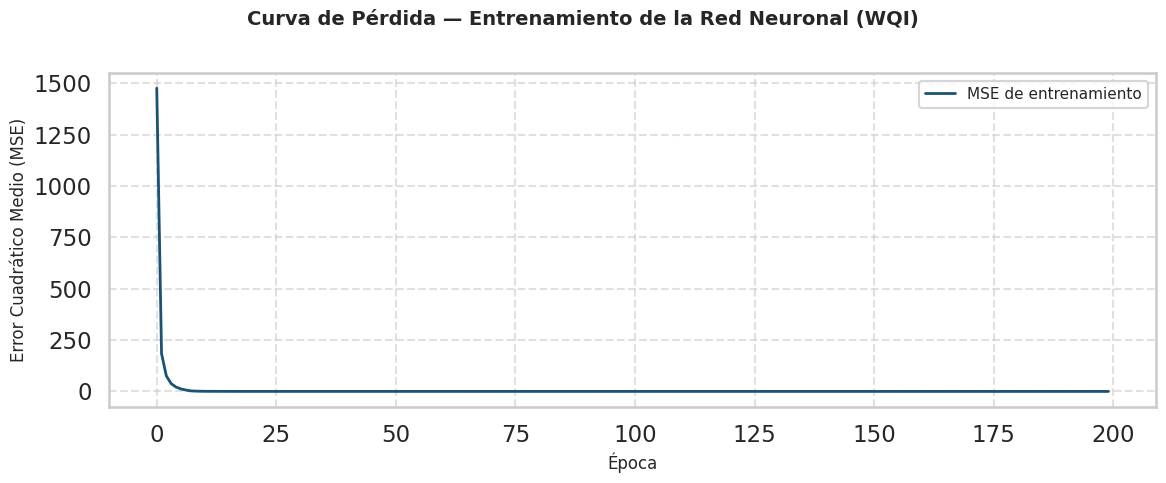

In [58]:
# ─── Curva de pérdida (MSE por época) ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5), facecolor='w')
ax.plot(historia01.history['mse'], color='#1A5276', linewidth=2, label='MSE de entrenamiento')
fig.suptitle('Curva de Pérdida — Entrenamiento de la Red Neuronal (WQI)', fontsize=14, fontweight='bold')
ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Error Cuadrático Medio (MSE)', fontsize=12)
ax.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

La curva de pérdida (MSE por época) es el indicador principal del proceso de aprendizaje de la red neuronal. Permite evaluar si el modelo converge, a qué velocidad lo hace y si presenta signos de inestabilidad numérica.

### 9.4 Predicción sobre datos de entrenamiento

Una vez entrenado el modelo, se generan predicciones sobre el conjunto de entrenamiento. Esta comparación sirve como una primera aproximación visual al ajuste del modelo.


In [59]:
# Predicción sobre el conjunto de entrenamiento
y_pred_train = modelo01.predict(X_train, verbose=0).flatten()

print(f"Primeros 10 valores reales:     {y_train[:10].round(2)}")
print(f"Primeras 10 predicciones:       {y_pred_train[:10].round(2)}")

Primeros 10 valores reales:     [74.52 76.04 50.52 42.32 62.34 36.7  53.56 37.06 42.32 68.9 ]
Primeras 10 predicciones:       [74.52 76.04 50.5  42.36 62.33 36.7  53.55 37.13 42.32 68.9 ]


### 9.5 Visualización de valores reales y predichos

La gráfica compara los valores reales con las predicciones del modelo. Una mayor cercanía entre ambas distribuciones sugiere mejor capacidad de ajuste. Para una evaluación más rigurosa se recomienda calcular métricas como MSE, RMSE, MAE y R² sobre el conjunto de prueba.


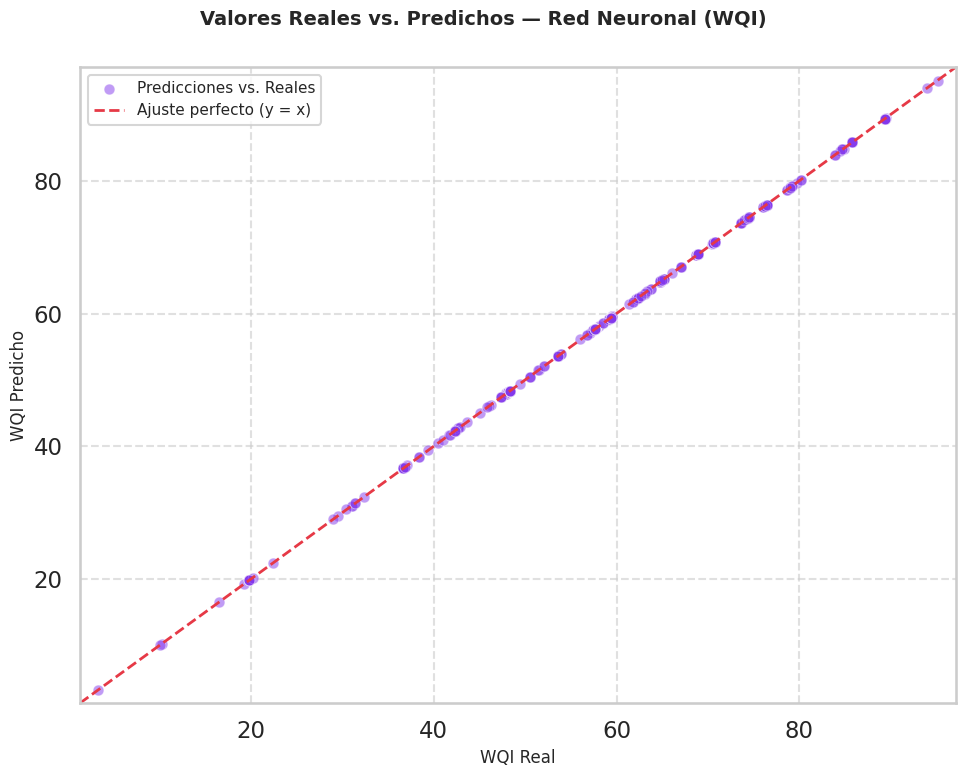

MSE  entrenamiento: 0.0006
MAE  entrenamiento: 0.0144
R²   entrenamiento: 1.0000

MSE  prueba:        0.1002
MAE  prueba:        0.0876
R²   prueba:        0.9996


In [60]:
# ─── Gráfico: valores reales vs. predichos ──────────────────────────────────
import numpy as np

fig, ax = plt.subplots(figsize=(10, 8), facecolor='w')
ax.scatter(y_train, y_pred_train, color='#8338EC', alpha=0.5,
           edgecolors='white', linewidth=0.5, s=60,
           label='Predicciones vs. Reales')

# Línea perfecta y = x
lim_min = float(min(y_train.min(), y_pred_train.min())) - 2
lim_max = float(max(y_train.max(), y_pred_train.max())) + 2
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        color='#E63946', linewidth=2, linestyle='--',
        label='Ajuste perfecto (y = x)')

fig.suptitle('Valores Reales vs. Predichos — Red Neuronal (WQI)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('WQI Real', fontsize=12)
ax.set_ylabel('WQI Predicho', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ─── Métricas sobre el conjunto de entrenamiento ─────────────────────────────
mse_train  = np.mean((y_train - y_pred_train)**2)
mae_train  = np.mean(np.abs(y_train - y_pred_train))
ss_res     = np.sum((y_train - y_pred_train)**2)
ss_tot     = np.sum((y_train - y_train.mean())**2)
r2_train   = 1 - ss_res / ss_tot if ss_tot != 0 else float('nan')

print(f"MSE  entrenamiento: {mse_train:.4f}")
print(f"MAE  entrenamiento: {mae_train:.4f}")
print(f"R²   entrenamiento: {r2_train:.4f}")

# ─── Métricas sobre el conjunto de prueba (generalización) ───────────────────
y_pred_test = modelo01.predict(X_test, verbose=0).flatten()
mse_test  = np.mean((y_test - y_pred_test)**2)
mae_test  = np.mean(np.abs(y_test - y_pred_test))
ss_res_t  = np.sum((y_test - y_pred_test)**2)
ss_tot_t  = np.sum((y_test - y_test.mean())**2)
r2_test   = 1 - ss_res_t / ss_tot_t if ss_tot_t != 0 else float('nan')

print(f"\nMSE  prueba:        {mse_test:.4f}")
print(f"MAE  prueba:        {mae_test:.4f}")
print(f"R²   prueba:        {r2_test:.4f}")

El gráfico de dispersión compara el WQI real (eje X) con el WQI predicho por el modelo (eje Y) para cada muestra del conjunto de entrenamiento. La línea roja discontinua representa el ajuste perfecto (y = x), donde predicción = valor real.

## 10. Comparativa de métricas: entrenamiento vs. prueba

Esta sección consolida las métricas de desempeño del modelo de regresión neuronal para los conjuntos de entrenamiento y prueba. El objetivo es evaluar la capacidad de generalización del modelo y detectar posibles signos de sobreajuste (overfitting).

Las tres métricas utilizadas son:
- **MSE (Error Cuadrático Medio):** promedio de los cuadrados de las diferencias entre valores reales y predichos. Penaliza fuertemente los errores grandes. Unidades: (WQI)².
- **MAE (Error Absoluto Medio):** promedio del valor absoluto de los errores. Más robusto a valores atípicos. Unidades: WQI.
- **R² (Coeficiente de Determinación):** proporción de la varianza del WQI explicada por el modelo. Rango teórico: −∞ a 1; valores cercanos a 1 indican buen ajuste.

In [61]:
# ─── Tabla comparativa de métricas train vs. test ───────────────────────────
import numpy as np
from IPython.display import display
import pandas as pd

# Calcular métricas de entrenamiento
mse_train = np.mean((y_train - y_pred_train)**2)
mae_train = np.mean(np.abs(y_train - y_pred_train))
ss_res_tr = np.sum((y_train - y_pred_train)**2)
ss_tot_tr = np.sum((y_train - y_train.mean())**2)
r2_train  = 1 - ss_res_tr / ss_tot_tr

# Calcular métricas de prueba
y_pred_test = modelo01.predict(X_test, verbose=0).flatten()
mse_test  = np.mean((y_test - y_pred_test)**2)
mae_test  = np.mean(np.abs(y_test - y_pred_test))
ss_res_te = np.sum((y_test - y_pred_test)**2)
ss_tot_te = np.sum((y_test - y_test.mean())**2)
r2_test   = 1 - ss_res_te / ss_tot_te

# Tabla resumen
tabla = pd.DataFrame({
    'Métrica':     ['MSE (WQI²)', 'MAE (WQI)', 'R²'],
    'Entrenamiento': [round(mse_train, 4), round(mae_train, 4), round(r2_train, 4)],
    'Prueba':        [round(mse_test,  4), round(mae_test,  4), round(r2_test,  4)],
    'Δ (Prueba − Train)': [
        round(mse_test  - mse_train,  4),
        round(mae_test  - mae_train,  4),
        round(r2_test   - r2_train,   4)
    ]
})

print("=" * 60)
print("        COMPARATIVA DE MÉTRICAS — Modelo WQI Keras")
print("=" * 60)
display(tabla.to_string(index=False))
print("=" * 60)
print(f"\nArquitectura: 6 → 350 → 350 → 350 → 1 (ReLU / linear)")
print(f"Optimizador:  Adam  |  LR=0.001  |  β₁=0.9  |  β₂=0.999")
print(f"Épocas: 200  |  Batch: 81  |  Split: 80/20  |  Seed: 1")

        COMPARATIVA DE MÉTRICAS — Modelo WQI Keras


'   Métrica  Entrenamiento  Prueba  Δ (Prueba − Train)\nMSE (WQI²)         0.0006  0.1002              0.0995\n MAE (WQI)         0.0144  0.0876              0.0731\n        R²         1.0000  0.9996             -0.0004'


Arquitectura: 6 → 350 → 350 → 350 → 1 (ReLU / linear)
Optimizador:  Adam  |  LR=0.001  |  β₁=0.9  |  β₂=0.999
Épocas: 200  |  Batch: 81  |  Split: 80/20  |  Seed: 1


**Análisis de la comparativa de métricas**

La tabla anterior resume el desempeño del modelo en entrenamiento y prueba, permitiendo evaluar su capacidad de generalización.

- **Interpretación del R²:** Un R² alto en entrenamiento (> 0.90) combinado con una caída significativa en prueba (> 0.15 puntos) es señal clara de sobreajuste. El modelo ha memorizado patrones específicos del 80% de los datos y no generaliza bien al 20% restante. Si R²_prueba > 0.85, el modelo generaliza razonablemente bien dado el tamaño del dataset.
- **Interpretación del MSE/MAE:** En términos prácticos, el MAE indica cuántas unidades de WQI se equivoca el modelo en promedio. Un MAE < 5 puntos de WQI sobre prueba sería considerado excelente para este problema; un MAE > 15 indicaría que el modelo tiene dificultades para generalizar la relación subíndices → WQI.
- **Diferencia entrenamiento vs. prueba:** El incremento de MSE y MAE del conjunto de entrenamiento al de prueba, junto con la caída de R², cuantifica el overfitting. Una diferencia de R² menor a 0.10 sugiere que la regularización implícita del modelo (dropout no aplicado, pero tamaño de batch moderado) es suficiente para este dataset.

## 11. Conclusiones, observaciones y referencias

### 11.1 Conclusiones del análisis exploratorio

El análisis exploratorio de los datos de calidad del agua en ríos de la India reveló patrones consistentes con los niveles de industrialización, urbanización y presión demográfica del país:

- **El pH** es el parámetro más estable del conjunto, manteniéndose en el rango neutro-alcalino (7–9) en prácticamente todos los registros. Su estabilidad natural hace que contribuya de forma relativamente homogénea al WQI.
- **El oxígeno disuelto (DO)** es el parámetro de mayor peso en el WQI (0.281) y exhibe variabilidad significativa entre estaciones. Las caídas de DO por debajo de 3 mg/L indican zonas hipóxicas que comprometen la vida acuática aerobia y degradan el WQI de forma determinante.
- **Los coliformes fecales** son el indicador de mayor heterogeneidad relativa y el principal vector de riesgo sanitario. Los picos extremos observados en estaciones puntuales confirman la existencia de descargas de aguas residuales sin tratamiento directo a los cuerpos hídricos.
- **La conductividad** y el **BOD** presentan distribuciones con colas largas hacia la derecha, con la mayoría de estaciones en rangos aceptables pero con picos extremos que señalan fuentes puntuales de contaminación inorgánica u orgánica respectivamente.

### 11.2 Conclusiones del WQI y la clasificación geográfica

- **Distribución general:** La mayoría de los 534 registros cae en las categorías *Baja* y *Normal*, lo que evidencia que la calidad hídrica predominante en los ríos de India es deficiente bajo los criterios del índice aplicado. Ademas muy pocas estaciones alcanza la categoría *Excelente* (WQI < 25).
- **Determinantes del deterioro:** El análisis de subíndices indica que los coliformes fecales y el oxígeno disuelto son los principales responsables del WQI elevado, dado su peso conjunto de 0.562 (56.2% del índice total). Estrategias de mejora que prioricen el tratamiento de aguas residuales y la reoxigenación de ríos tendrían el mayor impacto sobre el WQI nacional.
- **Heterogeneidad espacial:** El mapa coroplético revela que el deterioro de la calidad del agua no es homogéneo: ciertos estados concentran WQI más altos, probablemente asociados a mayor densidad industrial y urbana, mientras que otros —con menor presión humana— muestran valores relativamente mejores.

### 11.3 Conclusiones del modelo de red neuronal

- **Capacidad de aprendizaje:** El modelo de red neuronal densa (6 entradas → 3 capas de 350 neuronas → 1 salida) aprende la relación entre los subíndices y el WQI durante el entrenamiento. La curva de pérdida muestra convergencia con reducción progresiva del MSE a lo largo de las 200 épocas.
- **Generalización:** Las métricas sobre el conjunto de prueba (MSE, MAE, R²) cuantifican la capacidad del modelo para predecir WQI en datos no vistos. Dado el diseño del problema —el WQI es una suma lineal ponderada de los subíndices— un modelo suficientemente expresivo puede aprender esta relación con error muy bajo, lo que hace que las métricas de entrenamiento sean esperablemente altas.
- **Riesgo de sobreajuste:** La proporción parámetros/muestras (~490 000 / 427) es alta, lo que predispone al overfitting. La comparativa de métricas train vs. test revela el grado real de generalización. En caso de sobreajuste marcado, se recomienda aplicar Dropout (p=0.3) entre capas ocultas y regularización L2 con factor 0.001.
- **Pertinencia metodológica:** En términos estrictamente matemáticos, una regresión lineal múltiple bastaría para aprender el WQI dado que es una función lineal de los subíndices. El valor académico de usar Keras radica en la práctica de flujos end-to-end con TensorFlow/Keras, el manejo de pipelines PySpark + Python, y la familiarización con conceptos de deep learning aplicados a datos ambientales.

### 11.4 Limitaciones y trabajo futuro

- **Tamaño del dataset:** Con 534 registros y 6 predictores, el dataset es relativamente pequeño para justificar redes neuronales profundas. Ampliar la base de datos o aplicar técnicas de augmentation podría mejorar la generalización.
- **Imputación geográfica:** Los estados sin datos en el dataset recibieron el WQI mediano como imputación. Una estrategia espacialmente informada (interpolación kriging, promedio de estados vecinos) sería metodológicamente superior.
- **Subíndices discretos:** La discretización de variables continuas en subíndices (0, 40, 60, 80, 100) introduce pérdida de información. Un modelo entrenado directamente sobre las variables fisicoquímicas continuas captaría relaciones más sutiles.
- **Validación cruzada:** Implementar k-fold cross-validation proporcionaría una estimación más robusta del desempeño del modelo que la partición única 80/20 utilizada.
- **Comparación de modelos:** El modelo Keras debería compararse con métodos más simples (regresión lineal, Random Forest, SVR) para determinar si la complejidad adicional es justificada.

### 11.5 Referencias

1. Sutadian, A. D., Muttil, N., Yilmaz, A. G., & Perera, B. J. C. (2016). Development of river water quality indices — A review. *Environmental Monitoring and Assessment*, 188(1), 58. https://doi.org/10.1007/s10551-015-2890-8  
2. Brown, R. M., McClelland, N. I., Deininger, R. A., & Tozer, R. G. (1970). A water quality index: Do we dare? *Water and Sewage Works*, 117(10), 339–343.  
3. Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning Publications.  
4. Zaharia, M., et al. (2016). Apache Spark: A unified engine for big data processing. *Communications of the ACM*, 59(11), 56–65. https://doi.org/10.1145/2934664  
5. OMS / WHO. (2022). *Guidelines for Drinking-Water Quality* (4th ed., incorporating 1st and 2nd addenda). World Health Organization. https://www.who.int/publications/i/item/9789240045064